# **Problem Statement 1**

**1.	API Data Retrieval and Storage: You are tasked with fetching data from an external REST API, storing it in a local SQLite database, and displaying the retrieved data. The API provides a list of books in JSON format with attributes like title, author, and publication year.**

In [70]:
import sqlite3
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [71]:
DB_PATH = "assignment.db"

def get_conn():
    conn = sqlite3.connect(DB_PATH)
    conn.execute("PRAGMA foreign_keys = ON")
    return conn

print("Database configuration ready.")

Database configuration ready.


In [72]:
API_URL = "https://openlibrary.org/search.json"
print("Books API:", API_URL)

Books API: https://openlibrary.org/search.json


In [73]:
def fetch_books(query="python programming", limit=10):
    params = {
        "q": query,
        "limit": limit,
        "fields": "key,title,author_name,first_publish_year"
    }

    response = requests.get(
        API_URL,
        params=params,
        timeout=10
    )

    response.raise_for_status()
    return response.json().get("docs", [])
books_raw = fetch_books()
print("Number of books retrieved:", len(books_raw))

Number of books retrieved: 10


In [74]:
print(books_raw[0])

{'author_name': ['R. Nageswara Rao'], 'first_publish_year': 2016, 'key': '/works/OL30906747W', 'title': 'Core Python Programming'}


In [75]:
def normalize_book(book):
    title = (book.get("title") or "").strip()

    authors = book.get("author_name") or []
    author = ", ".join(authors) if authors else "Unknown"

    year = book.get("first_publish_year")

    return {
        "title": title,
        "author": author,
        "publication_year": year
    }

books = [normalize_book(book) for book in books_raw]

print("Books processed:", len(books))

Books processed: 10


In [76]:
books_df = pd.DataFrame(books)
books_df

,title,author,publication_year
0,Core Python Programming,R. Nageswara Rao,2016
1,Black Hat Python,"Justin Seitz, Tim Arnold",2014
2,Core Python programming,Wesley Chun,2006
3,Python Programming,Reema Thareja,2019
4,Python programming,John M. Zelle,2003
5,Python,Joshua Welsh,2017
6,Learning Python,"Mark Lutz, David Ascher",1999
7,Python Programming,Sarah Stewart,2019
8,Python Programming Crash Course,Alex Jaxson,2022
9,Python Programming,Adam Stewart,2016


In [77]:
conn = get_conn()

conn.execute("""
CREATE TABLE IF NOT EXISTS books (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT NOT NULL,
    author TEXT,
    publication_year INTEGER
)
""")

conn.commit()

print("Books table created successfully.")

Books table created successfully.


In [78]:
conn.execute("DELETE FROM books")

conn.executemany("""
INSERT INTO books (title, author, publication_year)
VALUES (?, ?, ?)
""", [
    (
        book["title"],
        book["author"],
        book["publication_year"]
    )
    for book in books
])

conn.commit()

print("Books inserted into SQLite successfully.")

Books inserted into SQLite successfully.


In [79]:
stored_books = pd.read_sql("""
SELECT title, author, publication_year
FROM books
""", conn)

stored_books

,title,author,publication_year
0,Core Python Programming,R. Nageswara Rao,2016
1,Black Hat Python,"Justin Seitz, Tim Arnold",2014
2,Core Python programming,Wesley Chun,2006
3,Python Programming,Reema Thareja,2019
4,Python programming,John M. Zelle,2003
5,Python,Joshua Welsh,2017
6,Learning Python,"Mark Lutz, David Ascher",1999
7,Python Programming,Sarah Stewart,2019
8,Python Programming Crash Course,Alex Jaxson,2022
9,Python Programming,Adam Stewart,2016


**2.	Data Processing and Visualization: Given a dataset containing information about students' test scores, fetch the data from an API, calculate the average score, and create a bar chart to visualize the data.**

In [80]:
SCORES_API_URL = (
    "https://api.slingacademy.com/v1/sample-data/files/"
    "student-scores.json"
)

print("Student scores API configured.")

Student scores API configured.


In [81]:
def fetch_student_scores(url):
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return response.json()

student_data = fetch_student_scores(SCORES_API_URL)

print("Data fetched successfully.")
print(type(student_data))

Data fetched successfully.
<class 'list'>


In [82]:
print(student_data[:2])

[{'id': 1, 'first_name': 'Paul', 'last_name': 'Casey', 'email': 'paul.casey.1@gslingacademy.com', 'gender': 'male', 'part_time_job': False, 'absence_days': 3, 'extracurricular_activities': False, 'weekly_self_study_hours': 27, 'career_aspiration': 'Lawyer', 'math_score': 73, 'history_score': 81, 'physics_score': 93, 'chemistry_score': 97, 'biology_score': 63, 'english_score': 80, 'geography_score': 87}, {'id': 2, 'first_name': 'Danielle', 'last_name': 'Sandoval', 'email': 'danielle.sandoval.2@gslingacademy.com', 'gender': 'female', 'part_time_job': False, 'absence_days': 2, 'extracurricular_activities': False, 'weekly_self_study_hours': 47, 'career_aspiration': 'Doctor', 'math_score': 90, 'history_score': 86, 'physics_score': 96, 'chemistry_score': 100, 'biology_score': 90, 'english_score': 88, 'geography_score': 90}]


In [83]:
scores_df = pd.DataFrame(student_data)
scores_df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [84]:
scores_df["student"] = (
    scores_df["first_name"] + " " + scores_df["last_name"]
)

student_scores = scores_df[["student", "math_score"]].copy()
student_scores.head(10)

,student,math_score
0,Paul Casey,73
1,Danielle Sandoval,90
2,Tina Andrews,81
3,Tara Clark,71
4,Anthony Campos,84
5,Kelly Wade,93
6,Anthony Smith,99
7,George Short,95
8,Stanley Gutierrez,94
9,Audrey Simpson,98


In [85]:
student_scores["math_score"] = pd.to_numeric(
    student_scores["math_score"],
    errors="coerce"
)

student_scores = student_scores.dropna(
    subset=["math_score"]
)

student_scores = student_scores[
    student_scores["math_score"].between(0, 100)
]

print("Valid student records:", len(student_scores))

Valid student records: 2000


In [86]:
chart_data = student_scores.head(10)
chart_data

,student,math_score
0,Paul Casey,73
1,Danielle Sandoval,90
2,Tina Andrews,81
3,Tara Clark,71
4,Anthony Campos,84
5,Kelly Wade,93
6,Anthony Smith,99
7,George Short,95
8,Stanley Gutierrez,94
9,Audrey Simpson,98


In [87]:
average_score = chart_data["math_score"].mean()
print(f"Average Mathematics Score: {average_score:.2f}")

Average Mathematics Score: 87.80


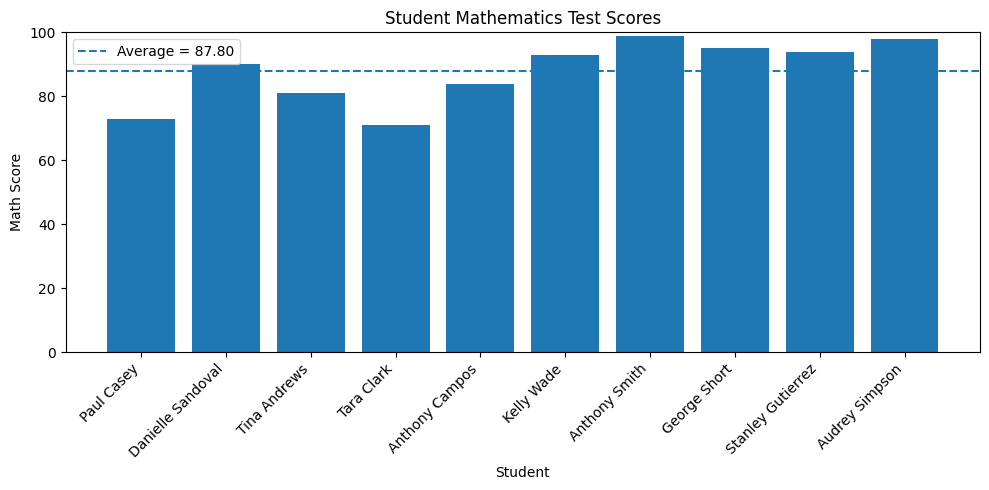

In [88]:
plt.figure(figsize=(10, 5))

plt.bar(
    chart_data["student"],
    chart_data["math_score"]
)

plt.axhline(
    average_score,
    linestyle="--",
    label=f"Average = {average_score:.2f}"
)

plt.xlabel("Student")
plt.ylabel("Math Score")
plt.title("Student Mathematics Test Scores")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()

plt.savefig(
    "student_scores.png",
    dpi=150
)

plt.show()

**3.	CSV Data Import to a Database: Write a Python script that reads data from a CSV file containing user information (e.g., name, email) and inserts it into a SQLite database.**

**Assumption:** Since the assignment does not provide a specific CSV file, a sample users.csv file containing name and email fields was created in the Colab runtime to demonstrate the import workflow.

In [89]:
sample_csv = """name,email
Alice Johnson,alice@example.com
Bob Smith,bob@example.com
Carol White,carol@example.com
Dev Patel,dev@example.org
Priya Shah,priya@example.com
"""

with open("users.csv", "w", encoding="utf-8") as file:
    file.write(sample_csv)

print("users.csv created in the Colab runtime.")

users.csv created in the Colab runtime.


In [90]:
print("File exists:", os.path.exists("users.csv"))
print("File location:", os.path.abspath("users.csv"))

File exists: True
File location: /content/users.csv


In [91]:
users_df = pd.read_csv("users.csv")
users_df

,name,email
0,Alice Johnson,alice@example.com
1,Bob Smith,bob@example.com
2,Carol White,carol@example.com
3,Dev Patel,dev@example.org
4,Priya Shah,priya@example.com


In [92]:
conn.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    email TEXT NOT NULL UNIQUE
)
""")

conn.commit()

print("Users table created.")

Users table created.


In [93]:
for _, row in users_df.iterrows():
    conn.execute(
        """
        INSERT OR IGNORE INTO users (name, email)
        VALUES (?, ?)
        """,
        (
            row["name"],
            row["email"]
        )
    )

conn.commit()

print("CSV data inserted into SQLite successfully.")

CSV data inserted into SQLite successfully.


In [94]:
stored_users = pd.read_sql_query(
    """
    SELECT id, name, email
    FROM users
    """,
    conn
)

stored_users

,id,name,email
0,1,Alice Johnson,alice@example.com
1,2,Bob Smith,bob@example.com
2,3,Carol White,carol@example.com
3,4,Dev Patel,dev@example.org
4,5,Priya Shah,priya@example.com


In [95]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    """,
    conn
)

tables

,name
0,books
1,sqlite_sequence
2,users


In [96]:
print("Database exists:", os.path.exists("assignment.db"))
print("Database size:", os.path.getsize("assignment.db"), "bytes")

Database exists: True
Database size: 20480 bytes


In [97]:
print("Books stored:", pd.read_sql_query(
    "SELECT COUNT(*) AS count FROM books", conn
)["count"].iloc[0])

print("Users stored:", pd.read_sql_query(
    "SELECT COUNT(*) AS count FROM users", conn
)["count"].iloc[0])

Books stored: 10
Users stored: 5


In [98]:
conn.close()
print("SQLite connection closed successfully.")

SQLite connection closed successfully.
